# Fase 3 · Índice histórico de postura (Bloque 2)

**Objetivo:** puntuar la postura de las 55 ruedas de prensa de la era Lagarde con el modelo elegido en la fase 2 (Qwen3 8B) y comprobar que el índice resultante se comporta como cabe esperar frente a las decisiones de tipos. El índice alimenta la pestaña Histórico de la aplicación y el percentil de cada rueda en el informe.

In [1]:
# autoreload solo vigila nuestro código (src), no las librerías instaladas
%load_ext autoreload
%autoreload 1
%aimport src.config, src.text.stance, src.text.history

import matplotlib.pyplot as plt
import pandas as pd

from src.config import ROOT, HISTORY_DIR
from src.text.history import (decisiones_de_tipos, indice_historico, medias_por_decision,
                              correlaciones_con_decisiones)

resultados_dir = ROOT / "benchmarks" / "results" / "historico"
resultados_dir.mkdir(parents=True, exist_ok=True)

## 1. Clasificación de las frases

El script `scripts/postura_historico.py` aplica el modelo a todas las frases de la presidenta y del vicepresidente: declaración, respuestas e intervenciones fuera de pregunta. No se clasifican las preguntas de los periodistas ni las intervenciones de los gobernadores anfitriones, porque no expresan la postura del BCE. El resultado se guarda frase a frase en `data/history/stance_sentences.parquet`, que también podrán usar la pestaña Histórico y el chat.

In [2]:
frases = pd.read_parquet(HISTORY_DIR / "stance_sentences.parquet")
print(f"{len(frases)} frases de {frases['date'].nunique()} ruedas | modelo: {frases['model'].iloc[0]}")

# Proporción de cada etiqueta por sección y proporción de frases relevantes
resumen = pd.crosstab(frases["section"], frases["label"], normalize="index")
resumen["relevantes"] = frases.groupby("section")["relevant"].mean()
resumen.round(3)

12333 frases de 55 ruedas | modelo: mlx-community/Qwen3-8B-4bit


label,dovish,hawkish,neutral,relevantes
section,,,,
qa,0.041,0.089,0.870,0.670
statement,0.128,0.180,0.692,0.836


## 2. Puntuación de cada rueda

- **Peso de cada frase.** Cada frase pesa su probabilidad de ser relevante (`1 − p_irrelevant`): un saludo pesa casi 0 y una frase con postura clara, casi 1. En la fase 2, la detección de frases irrelevantes fue la parte más débil del modelo (F1 ≈ 0,54): filtrarlas descartaría casi la mitad de las frases relevantes mal marcadas y conservaría la mitad de las irrelevantes, mientras que ponderar atenúa ambos errores. Contarlas todas igual diluiría la puntuación hacia cero con saludos y fórmulas.
- **Declaración y respuestas.** La puntuación global pondera al 50 % la declaración, mensaje oficial acordado por el Consejo de Gobierno, y las respuestas, mensaje espontáneo de la presidenta. Con la media de todas las frases, las respuestas pesarían unos dos tercios, pero esa proporción variaría con la duración del turno de preguntas y añadiría ruido al comparar ruedas. Ambas puntuaciones se conservan por separado.
- **Percentil.** Porcentaje de ruedas del histórico con una puntuación igual o inferior: sitúa cada rueda frente a las demás en el informe.

In [3]:
corpus = pd.read_parquet(HISTORY_DIR / "transcripts.parquet")
listado = pd.read_csv(HISTORY_DIR / "press_conferences.csv")

decisiones = decisiones_de_tipos(corpus)
indice = indice_historico(frases, listado, decisiones)
indice.to_csv(HISTORY_DIR / "stance_by_conference.csv", index=False)

print(f"Guardado: {HISTORY_DIR / 'stance_by_conference.csv'} ({len(indice)} ruedas)")
indice.drop(columns="url").round(3)

Guardado: /Users/eduardogonzalezarroyo/Developer/hawk-and-dove_BCE/data/history/stance_by_conference.csv (55 ruedas)


,date,score,score_statement,score_qa,n_sentences,decision,percentile
0,2019-12-12,-0.052,-0.057,-0.047,253,mantenimiento,20
1,2020-01-23,-0.021,-0.047,0.005,259,mantenimiento,27
2,2020-03-12,-0.215,-0.349,-0.081,173,mantenimiento,11
3,2020-04-30,-0.278,-0.385,-0.171,244,mantenimiento,2
4,2020-06-04,-0.229,-0.415,-0.043,225,mantenimiento,7
5,2020-07-16,-0.215,-0.310,-0.120,239,mantenimiento,9
6,2020-09-10,-0.183,-0.274,-0.092,212,mantenimiento,15
7,2020-10-29,-0.232,-0.311,-0.153,251,mantenimiento,5
8,2020-12-10,-0.264,-0.358,-0.171,223,mantenimiento,4
9,2021-01-21,-0.215,-0.268,-0.162,211,mantenimiento,13


## 3. Evolución del índice

Un punto por rueda; los triángulos marcan las reuniones con subida o bajada de tipos. Por encima de cero, el tono es hawkish; por debajo, dovish.

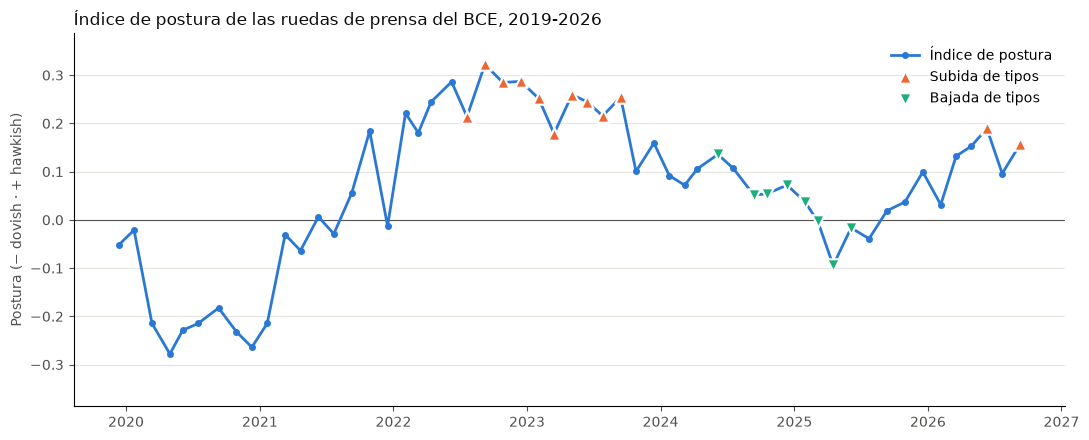

In [4]:
# Paleta categórica validada (tres primeras posiciones, en orden fijo); los textos van en tinta neutra
AZUL, NARANJA, AGUAMARINA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA_SECUNDARIA, REJILLA = "#0b0b0b", "#52514e", "#e6e5e0"

fechas = pd.to_datetime(indice["date"])
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axhline(0, color=TINTA_SECUNDARIA, linewidth=0.8)
ax.plot(fechas, indice["score"], color=AZUL, linewidth=2, marker="o", markersize=4,
        label="Índice de postura", zorder=2)

# Reuniones con cambio de tipos: la forma del marcador distingue subidas y bajadas además del color
for decision, marcador, color, etiqueta in [("subida", "^", NARANJA, "Subida de tipos"),
                                            ("bajada", "v", AGUAMARINA, "Bajada de tipos")]:
    seleccion = (indice["decision"] == decision).to_numpy()
    ax.scatter(fechas[seleccion], indice.loc[seleccion, "score"], marker=marcador, s=80, color=color,
               edgecolor="white", linewidth=1.5, zorder=3, label=etiqueta)

limite = indice["score"].abs().max() * 1.2   # eje simétrico: cero en el centro
ax.set_ylim(-limite, limite)
ax.set_ylabel("Postura (− dovish · + hawkish)", color=TINTA_SECUNDARIA)
ax.set_title("Índice de postura de las ruedas de prensa del BCE, 2019-2026", loc="left", color=TINTA)
ax.grid(axis="y", color=REJILLA, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=TINTA_SECUNDARIA)
ax.legend(frameon=False, loc="best")   # se coloca donde no tape puntos
fig.tight_layout()
fig.savefig(resultados_dir / "indice_postura.png", dpi=200)
plt.show()

## 4. Validación con las decisiones de tipos

- **Decisión de cada rueda.** Se extrae de la fórmula con que la declaración la anuncia ("decided to raise the three key ECB interest rates"). Cuando la fórmula no aparece, la rueda cae siempre entre diciembre de 2019 y junio de 2022, periodo en el que los tipos oficiales no cambiaron, y se asigna mantenimiento.
- **Sin circularidad.** Comparar la puntuación global con la decisión del día sería en parte circular: la declaración anuncia la propia decisión y el modelo lee ese anuncio como hawkish o dovish. Por eso la validación usa las respuestas, que no contienen el anuncio, y comprueba además si el tono de una rueda anticipa la decisión de la siguiente. La correlación de la declaración con la decisión del día se muestra solo como referencia.
- **Alcance.** Las decisiones se agrupan en ciclos (diez subidas seguidas en 2022-2023, ocho bajadas en 2024-2025), así que las observaciones no son independientes y los p-valores son optimistas: es una validación descriptiva, no un contraste formal.

In [5]:
# Decisiones extraídas y de dónde sale cada una
pd.crosstab(decisiones["decision"], decisiones["origen"], margins=True)

origen,declaración,periodo sin cambios,All
decision,,,
bajada,8,0,8
mantenimiento,22,13,35
subida,12,0,12
All,42,13,55


In [6]:
# Puntuación media de las respuestas según la decisión de la misma reunión y la de la siguiente
medias_por_decision(indice).round(3)

misma reunión       reunión siguiente      
                       mean count              mean count
bajada                0.059     8             0.064     8
mantenimiento         0.031    35             0.030    34
subida                0.185    12             0.179    12

In [7]:
# Correlación de Spearman con la decisión codificada (bajada = −1, mantenimiento = 0, subida = +1)
correlaciones_con_decisiones(indice).round(3)

,puntuacion,decision,rho_spearman,p_valor,n
0,Declaración,"misma reunión (referencia, en parte mecánica)",0.558,0.000,55
1,Respuestas,misma reunión,0.463,0.000,55
2,Respuestas,reunión siguiente,0.415,0.002,54
3,Global,reunión siguiente,0.492,0.000,54


## 5. Conclusiones

**El índice reproduce los grandes episodios de la política del BCE**, pese a que el modelo nunca ve la fecha: cada frase se clasifica de forma aislada.
- **Pandemia.** Mínimo de la serie en abril de 2020 (−0,28), con la relajación instrumentada mediante compras de activos y financiación a la banca.
- **Giro hawkish.** En febrero de 2022 el índice pasa de −0,01 a 0,22, más de cinco meses antes de la primera subida de tipos (julio de 2022).
- **Ciclo de subidas.** Máximo en septiembre de 2022 (0,32), con la subida de 75 pb. En marzo de 2023, en plena turbulencia bancaria, el índice marca su mínimo del ciclo (0,18), con las respuestas en 0,06.
- **Ciclo de bajadas.** La primera bajada, en junio de 2024, puntúa por encima del mantenimiento previo (0,14 frente a 0,11), en línea con su lectura como "bajada hawkish". El mínimo del ciclo llega en abril de 2025 (−0,09, el más bajo desde enero de 2021), tras el choque arancelario.
- **2026.** El índice sube desde marzo (de 0,03 a 0,13) con el choque energético, antes de las subidas de junio y septiembre.

**Validación con las decisiones de tipos: parcial.**
- La asociación es positiva y moderada. La correlación de Spearman es de 0,46 entre las respuestas y la decisión del día, y de 0,42 con la de la reunión siguiente. La de la declaración (0,56) solo sirve de referencia, porque es en parte mecánica.
- La sostienen las subidas. Las respuestas puntúan 0,185 de media en las reuniones con subida, frente a 0,031 en los mantenimientos y 0,059 en las bajadas: el índice no separa las bajadas de los mantenimientos.
- Hay tres explicaciones posibles, que estos datos no permiten distinguir:
  1. "Mantenimiento" mezcla regímenes opuestos. Por un lado, las ruedas de la pandemia, las más dovish de la muestra (con los tipos en su mínimo, la relajación se hizo con compras de activos); por otro, la meseta tras las subidas de 2023-2024.
  2. Las bajadas de 2024-2025 retiraban restricción con la inflación aún por encima del objetivo, y se comunicaron con prudencia. En ese ciclo, las respuestas (de −0,04 a 0,15) se mueven en el mismo rango que en los mantenimientos de 2023-2026 (de 0,00 a 0,14).
  3. El modelo detecta peor la postura dovish que la hawkish (F1 de 0,50 frente a 0,63 en la fase 2).
- **Anticipación.** Los dos ciclos de subidas vinieron precedidos de meses de índice al alza (desde febrero de 2022 y desde marzo de 2026). Antes del ciclo de bajadas no hubo un giro dovish comparable.
- **Alcance.** Las decisiones se agrupan en pocos ciclos, de modo que los p-valores son optimistas y la correlación con la reunión siguiente refleja en parte la persistencia de las decisiones. Es una validación descriptiva, no un contraste formal.

**Implicaciones.**
- El índice mide el tono de la comunicación (la narrativa sobre la inflación y la orientación de la política); no predice la decisión de tipos. Que una misma decisión llegue con tonos distintos, como la bajada hawkish de junio de 2024, es precisamente la información que aporta frente a la decisión publicada.
- El nivel absoluto depende del periodo: desde junio de 2021, 37 de 43 ruedas puntúan por encima de cero. Por eso el informe acompañará la puntuación de su percentil en el histórico. La rueda de referencia (10 de septiembre de 2026) puntúa 0,157, en el percentil 69.
- Para un producto dirigido a mesas de tesorería, la validación más exigente sería la reacción del mercado en la ventana de la rueda de prensa (base EA-MPD del BCE). Queda como extensión.